# ERC-8004 Agent Economy — BigQuery Analysis

Search / ranking / analytics layer for **ERC-8004 trustless agents** on Ethereum mainnet,
backed by Google BigQuery's public dataset. Built for the Google Cloud $5k bounty.

**Registries (Ethereum mainnet):**
| Registry | Address | Event topic0 |
|---|---|---|
| Identity   | `0x8004a169fb4a3325136eb29fa0ceb6d2e539a432` | `Registered` `0xca52e62c…449bc4a` |
| Reputation | `0x8004baa17c55a88189ae136b182e5fda19de9b63` | `NewFeedback` `0x6a4a6174…5e58febc` |

Data source: `bigquery-public-data.goog_blockchain_ethereum_mainnet_us.logs` (data starts 2026-01-28).


## 0. Setup

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from google.cloud import bigquery

# Standalone auth: point at the repo-local service-account key if not already set.
if not os.environ.get("GOOGLE_APPLICATION_CREDENTIALS"):
    for _k in ("../.secrets/gcp-key.json", ".secrets/gcp-key.json", "gcp-key.json"):
        if os.path.exists(_k):
            os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = os.path.abspath(_k); break

# Billing project — queries are billed here, but scan the PUBLIC dataset.
# Override via env: BQ_BILLING_PROJECT. Must have billing enabled (sandbox projects
# share a small daily free quota and will 403 once it's spent).
BILLING_PROJECT = os.environ.get("BQ_BILLING_PROJECT")

# Hard cap so a mis-pruned query can't run up cost.
# The logs table is 3.7 TB, partitioned by MONTH on block_timestamp and clustered on
# block_timestamp ONLY (NOT on address) -- so filtering by contract address does NOT
# reduce bytes scanned. Cost is driven by the date window x the topics/data columns.
# Each month of (topics+data) is ~40-50 GB. We default to a 30-day window to stay cheap.
MAX_BYTES_BILLED = int(os.environ.get("BQ_MAX_BYTES", 70_000_000_000))  # 70 GB ceiling

client = bigquery.Client(project=BILLING_PROJECT)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", None)

# ERC-8004 constants
IDENTITY    = "0x8004a169fb4a3325136eb29fa0ceb6d2e539a432"
REPUTATION  = "0x8004baa17c55a88189ae136b182e5fda19de9b63"
TOPIC_REGISTERED   = "0xca52e62c367d81bb2e328eb795f7c7ba24afb478408a26c0e201d155c449bc4a"
TOPIC_NEWFEEDBACK  = "0x6a4a61743519c9d648a14e6493f47dbe3ff1aa29e7785c96c8326a205e58febc"
LOGS  = "bigquery-public-data.goog_blockchain_ethereum_mainnet_us.logs"

# Date window. Full history starts 2026-01-28, but scanning all 5 months of the
# topics/data columns costs ~$1.20+ PER query. We default to the last 30 days to keep
# the whole notebook around $1. Set START="2026-01-28" + raise BQ_MAX_BYTES for full history.
START = os.environ.get("BQ_START", "2026-05-14")
print(f"date window: {START} -> now   (set BQ_START=2026-01-28 for full history)")

def q(sql: str) -> pd.DataFrame:
    """Run SQL, return DataFrame. Caps bytes billed and prints cost."""
    cfg = bigquery.QueryJobConfig(maximum_bytes_billed=MAX_BYTES_BILLED)
    job = client.query(sql, job_config=cfg)
    df = job.to_dataframe()
    gb = (job.total_bytes_billed or 0) / 1e9
    print(f"billed {gb:.3f} GB  (~${gb/1000*6.25:.4f})  |  {len(df)} rows")
    return df

print("client ready")

date window: 2026-05-14 -> now   (set BQ_START=2026-01-28 for full history)
client ready


## 1. Adoption curve

Daily new agent registrations from the Identity Registry `Registered` event.

> **Window note:** defaults to the last 30 days (`START`) to keep cost ~$1. The original
> launch spike (~13k agents on 2026-01-29/30) is outside this window. For the full adoption
> curve set `BQ_START=2026-01-28` and `BQ_MAX_BYTES=250000000000`, ~$1.20 for this query alone.

In [2]:
adoption = q(f"""
SELECT
  DATE(block_timestamp) AS day,
  COUNT(*)              AS new_agents
FROM `{LOGS}`
WHERE address = "{IDENTITY}"
  AND block_timestamp >= TIMESTAMP "{START}"
  AND topics[SAFE_OFFSET(0)] = "{TOPIC_REGISTERED}"
GROUP BY day
ORDER BY day
""")
adoption["cumulative"] = adoption["new_agents"].cumsum()
print("total agents registered:", int(adoption["new_agents"].sum()))
print("date range:", adoption["day"].min(), "->", adoption["day"].max())
adoption.tail()

/Users/lukefoster/Documents/Development/honeycomb/analysis/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


billed 43.530 GB  (~$0.2721)  |  30 rows
total agents registered: 2108
date range: 2026-05-14 -> 2026-06-12


,day,new_agents,cumulative
25,2026-06-08,17,1990
26,2026-06-09,9,1999
27,2026-06-10,28,2027
28,2026-06-11,50,2077
29,2026-06-12,31,2108


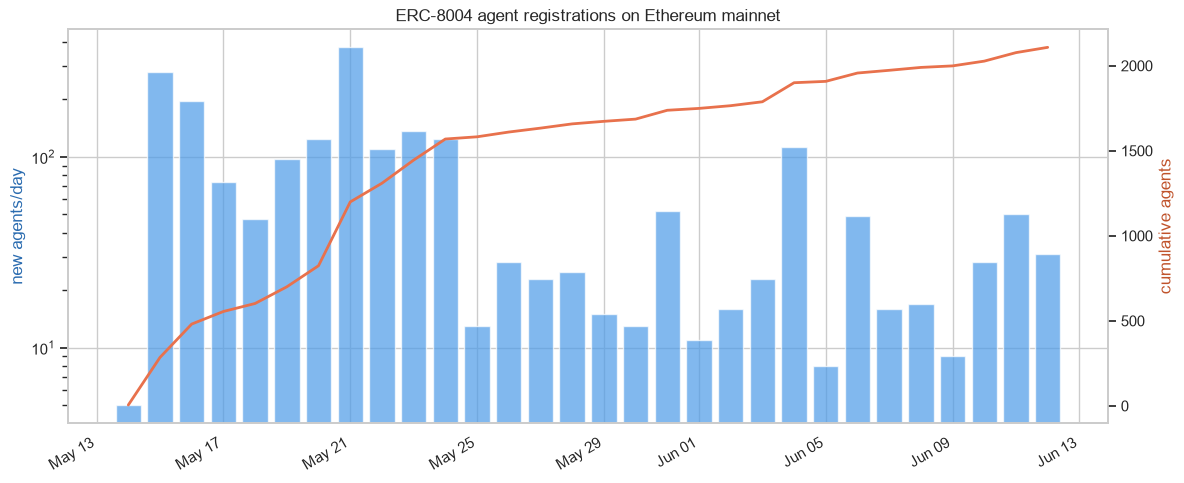

In [3]:
fig, ax1 = plt.subplots()
ax1.bar(adoption["day"], adoption["new_agents"], color="#4C9BE8", alpha=0.7, label="new agents/day")
ax1.set_ylabel("new agents/day", color="#2B6CB0")
ax1.set_yscale("log")  # launch spike dwarfs the tail; log keeps the tail readable

ax2 = ax1.twinx()
ax2.plot(adoption["day"], adoption["cumulative"], color="#E8714C", lw=2, label="cumulative")
ax2.set_ylabel("cumulative agents", color="#C0532B")
ax2.grid(False)

ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.title("ERC-8004 agent registrations on Ethereum mainnet")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 2. Reputation leaderboard

`NewFeedback` carries a signed fixed-point score: `int128 value` + `uint8 valueDecimals`.
We decode both from the `data` field by hex offset, normalize to `value / 10^valueDecimals`,
and rank by average score (min 3 unique clients to filter noise).

The `SUBSTR(data,67,1) != 'f'` guard drops negative (two's-complement) values.

In [4]:
leaderboard = q(f"""
WITH feedback AS (
  SELECT
    SAFE_CAST(topics[SAFE_OFFSET(1)] AS INT64)              AS agent_id,
    CONCAT("0x", SUBSTR(topics[SAFE_OFFSET(2)], 27))        AS client,
    SAFE_CAST(CONCAT("0x", SUBSTR(data,  67, 64)) AS INT64) AS raw_value,
    SAFE_CAST(CONCAT("0x", SUBSTR(data, 131, 64)) AS INT64) AS value_decimals
  FROM `{LOGS}`
  WHERE address = "{REPUTATION}"
    AND topics[SAFE_OFFSET(0)] = "{TOPIC_NEWFEEDBACK}"
    AND block_timestamp >= TIMESTAMP "{START}"
    AND SUBSTR(data, 67, 1) != "f"
)
SELECT
  agent_id,
  COUNT(*)                                           AS feedback_count,
  COUNT(DISTINCT client)                             AS unique_clients,
  ROUND(AVG(raw_value / POW(10, value_decimals)), 2) AS avg_score
FROM feedback
GROUP BY agent_id
HAVING unique_clients >= 3
ORDER BY avg_score DESC, unique_clients DESC
LIMIT 20
""")
leaderboard

/Users/lukefoster/Documents/Development/honeycomb/analysis/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


billed 68.679 GB  (~$0.4292)  |  1 rows


,agent_id,feedback_count,unique_clients,avg_score
0,34135,9,7,100.0


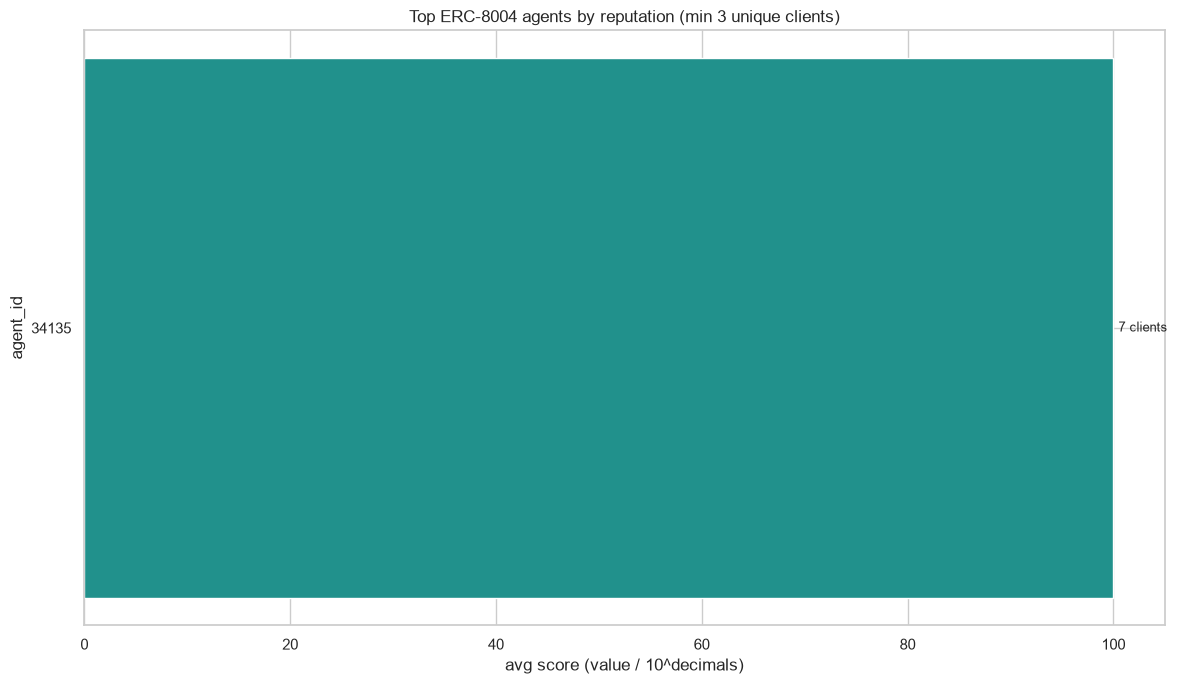

In [5]:
top = leaderboard.head(15).iloc[::-1]  # reverse so highest is at top of barh
colors = sns.color_palette("viridis", len(top))
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top["agent_id"].astype(str), top["avg_score"], color=colors)
ax.set_xlabel("avg score (value / 10^decimals)")
ax.set_ylabel("agent_id")
ax.set_title("Top ERC-8004 agents by reputation (min 3 unique clients)")
for bar, clients in zip(bars, top["unique_clients"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{int(clients)} clients", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### 2b. Trust signal — feedback vs. unique clients

Sequential `agent_id`s with identical low client counts can indicate batch/sybil feedback.
Plotting feedback_count against unique_clients surfaces agents whose reviews come from few
distinct addresses (points below the diagonal = repeat reviewers).

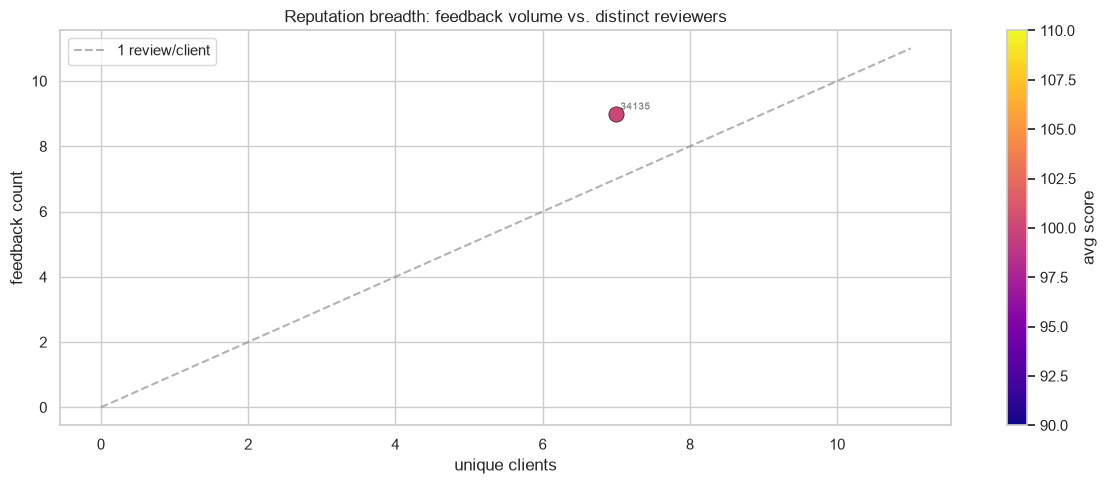

In [6]:
fig, ax = plt.subplots()
sc = ax.scatter(leaderboard["unique_clients"], leaderboard["feedback_count"],
                c=leaderboard["avg_score"], cmap="plasma", s=120, edgecolor="k", linewidth=0.5)
lim = max(leaderboard["unique_clients"].max(), leaderboard["feedback_count"].max()) + 2
ax.plot([0, lim], [0, lim], "--", color="gray", alpha=0.6, label="1 review/client")
ax.set_xlabel("unique clients")
ax.set_ylabel("feedback count")
ax.set_title("Reputation breadth: feedback volume vs. distinct reviewers")
ax.legend()
plt.colorbar(sc, label="avg score")
for _, r in leaderboard.iterrows():
    ax.annotate(int(r["agent_id"]), (r["unique_clients"], r["feedback_count"]),
                fontsize=7, alpha=0.7, xytext=(3, 3), textcoords="offset points")
plt.tight_layout()
plt.show()

## 3. Decode agent URIs (Identity Registry)

The `Registered` event packs `agentURI` as a dynamic string in `data`. Decode it,
then split fully-on-chain agents (`data:application/json;base64,…`) from IPFS/HTTPS ones.

In [7]:
agents = q(f"""
SELECT
  SAFE_CAST(topics[SAFE_OFFSET(1)] AS INT64)       AS agent_id,
  CONCAT("0x", SUBSTR(topics[SAFE_OFFSET(2)], 27)) AS owner,
  SAFE_CONVERT_BYTES_TO_STRING(FROM_HEX(SUBSTR(
    data, 131,
    2 * SAFE_CAST(CONCAT("0x", SUBSTR(data, 67, 64)) AS INT64)
  )))                                              AS agent_uri
FROM `{LOGS}`
WHERE address = "{IDENTITY}"
  AND topics[SAFE_OFFSET(0)] = "{TOPIC_REGISTERED}"
  AND block_timestamp >= TIMESTAMP "{START}"
""")

def uri_kind(u):
    if not isinstance(u, str) or not u:
        return "empty/unparsed"
    if u.startswith("data:application/json;base64,"):
        return "onchain (base64)"
    if u.startswith("ipfs://"):
        return "ipfs"
    if u.startswith("http"):
        return "https"
    return "other"

agents["uri_kind"] = agents["agent_uri"].map(uri_kind)
kind_counts = agents["uri_kind"].value_counts()
print(kind_counts)
agents.head()

/Users/lukefoster/Documents/Development/honeycomb/analysis/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


billed 68.679 GB  (~$0.4292)  |  2108 rows
uri_kind
https               1516
empty/unparsed       471
ipfs                  93
onchain (base64)      27
other                  1
Name: count, dtype: int64


,agent_id,owner,agent_uri,uri_kind
0,34002,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/1345,https
1,33047,0x7117246176a3bcbcb33b3b7144d5494f250c221e,ipfs://bafkreiaztsi6hjs2e74g2ca35n2izguzvl2vet...,ipfs
2,34030,0x671cf64e5c94b8468e6d5dac53aae5b048134f97,https://api.freaks.one/api/freak/9487,https
3,32944,0x671cf64e5c94b8468e6d5dac53aae5b048134f97,https://api.freaks.one/api/freak/5839,https
4,32945,0x671cf64e5c94b8468e6d5dac53aae5b048134f97,https://api.freaks.one/api/freak/8689,https


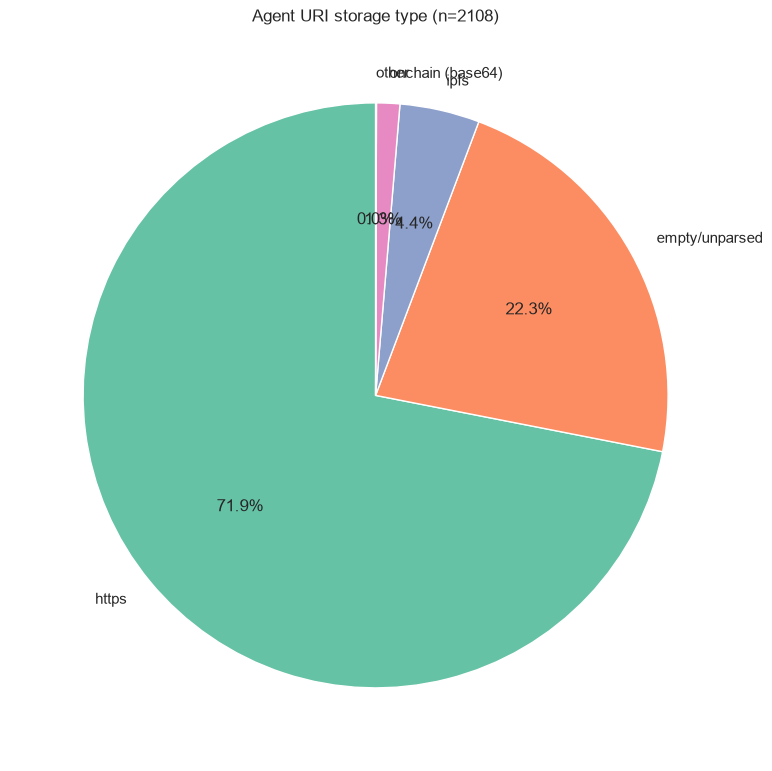

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(kind_counts, labels=kind_counts.index, autopct="%1.1f%%",
       colors=sns.color_palette("Set2", len(kind_counts)), startangle=90,
       wedgeprops=dict(edgecolor="w"))
ax.set_title(f"Agent URI storage type (n={len(agents)})")
plt.tight_layout()
plt.show()

## 4. Trustworthy **and** payable — the x402 join

The bounty's headline query. Join identity + reputation, and for fully-on-chain agents
decode the base64 registration JSON **inside SQL** to read `$.x402Support`.

> Caveat: this only catches agents whose registration is stored on-chain. IPFS/HTTPS
> agents need an off-chain fetch (see the `fetch_x402` helper below) to read x402Support.

In [9]:
payable = q(f"""
WITH agents AS (
  SELECT
    SAFE_CAST(topics[SAFE_OFFSET(1)] AS INT64)       AS agent_id,
    CONCAT("0x", SUBSTR(topics[SAFE_OFFSET(2)], 27)) AS owner,
    SAFE_CONVERT_BYTES_TO_STRING(FROM_HEX(SUBSTR(
      data, 131,
      2 * SAFE_CAST(CONCAT("0x", SUBSTR(data, 67, 64)) AS INT64)
    )))                                              AS agent_uri
  FROM `{LOGS}`
  WHERE address = "{IDENTITY}"
    AND topics[SAFE_OFFSET(0)] = "{TOPIC_REGISTERED}"
    AND block_timestamp >= TIMESTAMP "{START}"
),
scores AS (
  SELECT
    SAFE_CAST(topics[SAFE_OFFSET(1)] AS INT64) AS agent_id,
    COUNT(DISTINCT CONCAT("0x", SUBSTR(topics[SAFE_OFFSET(2)], 27))) AS unique_clients,
    ROUND(AVG(
      SAFE_CAST(CONCAT("0x", SUBSTR(data, 67, 64)) AS INT64) /
      POW(10, SAFE_CAST(CONCAT("0x", SUBSTR(data, 131, 64)) AS INT64))
    ), 2) AS avg_score
  FROM `{LOGS}`
  WHERE address = "{REPUTATION}"
    AND topics[SAFE_OFFSET(0)] = "{TOPIC_NEWFEEDBACK}"
    AND block_timestamp >= TIMESTAMP "{START}"
    AND SUBSTR(data, 67, 1) != "f"
  GROUP BY 1
)
SELECT
  a.agent_id, a.owner, a.agent_uri, s.avg_score, s.unique_clients,
  STARTS_WITH(a.agent_uri, "data:application/json;base64,") AS fully_onchain,
  IF(
    STARTS_WITH(a.agent_uri, "data:application/json;base64,"),
    JSON_VALUE(SAFE_CONVERT_BYTES_TO_STRING(SAFE.FROM_BASE64(
      SUBSTR(a.agent_uri, LENGTH("data:application/json;base64,") + 1)
    )), "$.x402Support"),
    NULL
  ) AS x402_support
FROM agents a
JOIN scores s USING (agent_id)
ORDER BY s.avg_score DESC
""")
print("agents with reputation:", len(payable))
print("fully on-chain:", int(payable["fully_onchain"].sum()))
print("x402_support values:\n", payable["x402_support"].value_counts(dropna=False))
payable.head(20)

/Users/lukefoster/Documents/Development/honeycomb/analysis/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


billed 68.679 GB  (~$0.4292)  |  51 rows
agents with reputation: 51
fully on-chain: 1
x402_support values:
 x402_support
NaN     50
true     1
Name: count, dtype: int64


,agent_id,owner,agent_uri,avg_score,unique_clients,fully_onchain,x402_support
0,32965,0xf42ef7177a57505d16d91bd3d6f88b0bbc35aa9b,"data:application/json;base64,eyJ0eXBlIjoiaHR0c...",100.0,1,True,true
1,34135,0x820c5091b047b652888f6aa7e1ee615d99f7c8cd,https://mcp.surfliquid.com/agent.json,100.0,7,False,NaN
2,32778,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/7528,95.0,1,False,NaN
3,32781,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/3012,95.0,1,False,NaN
4,32780,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/8055,95.0,1,False,NaN
5,32371,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/1608,95.0,1,False,NaN
6,32362,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/4354,95.0,1,False,NaN
7,32355,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/6352,95.0,1,False,NaN
8,33804,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/6595,95.0,1,False,NaN
9,32873,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/4035,95.0,1,False,NaN


### 4b. Off-chain x402 enrichment (optional)

For IPFS/HTTPS agents the on-chain JSON decode returns NULL. This helper fetches the
registration file and reads `x402Support`. Networked + slow, so it's capped and opt-in.

In [10]:
import json, urllib.request

def fetch_x402(uri, timeout=5):
    """Best-effort read of x402Support from an off-chain registration file. Loud on failure."""
    try:
        url = uri
        if uri.startswith("ipfs://"):
            url = "https://ipfs.io/ipfs/" + uri[len("ipfs://"):]
        with urllib.request.urlopen(url, timeout=timeout) as resp:
            doc = json.load(resp)
        return doc.get("x402Support")
    except Exception as e:
        print(f"  fetch failed for {uri[:60]}: {type(e).__name__}: {e}")
        return None

# Enrich the top off-chain agents only (cap to avoid hammering gateways).
offchain_top = payable[~payable["fully_onchain"]].head(10).copy()
if len(offchain_top):
    offchain_top["x402_offchain"] = offchain_top["agent_uri"].map(fetch_x402)
    display_cols = ["agent_id", "avg_score", "unique_clients", "agent_uri", "x402_offchain"]
    offchain_top[display_cols]
else:
    print("no off-chain agents with reputation in this slice")

  fetch failed for https://mcp.surfliquid.com/agent.json: HTTPError: HTTP Error 403: Forbidden


## 5. Combined view — the directory

Final ranked table: payable + reputable agents, x402 status resolved from on-chain
where possible. This is the data backing a directory/leaderboard frontend
(Cloud Run Next.js / Streamlit / Looker Studio).

In [11]:
directory = payable.copy()
directory["x402"] = directory["x402_support"].fillna("unknown")
directory = directory[["agent_id", "avg_score", "unique_clients", "x402", "fully_onchain", "owner", "agent_uri"]]

# headline counts
n_payable = (directory["x402"] == "true").sum()
print(f"{len(directory)} reputable agents | {n_payable} confirmed x402-payable (on-chain) | "
      f"{(directory['x402']=='unknown').sum()} unknown (off-chain, needs fetch)")

directory.head(25)

51 reputable agents | 1 confirmed x402-payable (on-chain) | 50 unknown (off-chain, needs fetch)


,agent_id,avg_score,unique_clients,x402,fully_onchain,owner,agent_uri
0,32965,100.0,1,true,True,0xf42ef7177a57505d16d91bd3d6f88b0bbc35aa9b,"data:application/json;base64,eyJ0eXBlIjoiaHR0c..."
1,34135,100.0,7,unknown,False,0x820c5091b047b652888f6aa7e1ee615d99f7c8cd,https://mcp.surfliquid.com/agent.json
2,32778,95.0,1,unknown,False,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/7528
3,32781,95.0,1,unknown,False,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/3012
4,32780,95.0,1,unknown,False,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/8055
5,32371,95.0,1,unknown,False,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/1608
6,32362,95.0,1,unknown,False,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/4354
7,32355,95.0,1,unknown,False,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/6352
8,33804,95.0,1,unknown,False,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/6595
9,32873,95.0,1,unknown,False,0xde152afb7db5373f34876e1499fbd893a82dd336,https://api.normies.art/agents/metadata/4035


In [12]:
# Export for the frontend
directory.to_csv("erc8004_directory.csv", index=False)
adoption.to_csv("erc8004_adoption.csv", index=False)
leaderboard.to_csv("erc8004_leaderboard.csv", index=False)
print("wrote erc8004_directory.csv, erc8004_adoption.csv, erc8004_leaderboard.csv")

wrote erc8004_directory.csv, erc8004_adoption.csv, erc8004_leaderboard.csv
